In [1]:
import torch
import torch.nn as nn
import numpy as np
import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torchvision.utils as vutils

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
LATENT_DIM   = 64
IM_CHANNELS  = 1
IM_SIZE      = (28, 28)
BATCH_SIZE   = 256
NUM_EPOCHS   = 500
NUM_SAMPLES  = 225
NROWS        = 15

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.latent_dim = LATENT_DIM
        self.img_size   = IM_SIZE
        self.channels   = IM_CHANNELS

        layer_dim = [
            self.latent_dim, 128, 256,
            self.img_size[0] * self.img_size[1] * self.channels
        ]

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_dim[i], layer_dim[i + 1]),
                nn.BatchNorm1d(layer_dim[i + 1]) if i != len(layer_dim) - 2 else nn.Identity(),
                nn.ReLU()  if i != len(layer_dim) - 2 else nn.Tanh()
            ) for i in range(len(layer_dim) - 1)
        ])

    def forward(self, z):
        out = z.reshape(-1, self.latent_dim)
        for layer in self.layers:
            out = layer(out)
        return out.reshape(out.size(0), self.channels, self.img_size[0], self.img_size[1])

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_size = IM_SIZE
        self.channels = IM_CHANNELS

        layer_dim = [
            self.img_size[0] * self.img_size[1] * self.channels,
            256, 128, 1
        ]

        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_dim[i], layer_dim[i + 1]),
                nn.LayerNorm(layer_dim[i + 1]) if i != len(layer_dim) - 2 else nn.Identity(),
                nn.LeakyReLU(0.2)              if i != len(layer_dim) - 2 else nn.Identity(),
                nn.Dropout(0.3)                if i != len(layer_dim) - 2 else nn.Identity()
            ) for i in range(len(layer_dim) - 1)
        ])

    def forward(self, x):
        out = x.reshape(-1, self.img_size[0] * self.img_size[1] * self.channels)
        for layer in self.layers:
            out = layer(out)
        return out

## Dataset

In [6]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

dataset    = MNIST(root='./data', download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.29MB/s]


In [7]:
def train_step(generator, discriminator, real_images, g_optimizer, d_optimizer, criterion):
    batch_size = real_images.size(0)

    # ── Discriminator ──────────────────────────────────────────────────────────
    d_optimizer.zero_grad()

    real_output  = discriminator(real_images)
    d_loss_real  = criterion(real_output, torch.ones_like(real_output))

    d_noise      = torch.randn(batch_size, LATENT_DIM, device=real_images.device)
    fake_images  = generator(d_noise).detach()
    fake_output  = discriminator(fake_images)
    d_loss_fake  = criterion(fake_output, torch.zeros_like(fake_output))

    d_loss = (d_loss_real + d_loss_fake) / 2
    d_loss.backward()
    d_optimizer.step()

    # ── Generator (1 update per D step) ────────────────────────────────────────
    g_optimizer.zero_grad()

    g_noise       = torch.randn(batch_size, LATENT_DIM, device=real_images.device)
    fake_images_g = generator(g_noise)
    fake_output_g = discriminator(fake_images_g)
    g_loss        = criterion(fake_output_g, torch.ones_like(fake_output_g))
    g_loss.backward()
    g_optimizer.step()

    return d_loss.item(), g_loss.item()

In [8]:
def save_generated_images(generator, fixed_noise, epoch, output_dir):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_noise).cpu()

    fake_images = (fake_images + 1) / 2.0
    grid_img    = vutils.make_grid(fake_images, nrow=NROWS, padding=2, normalize=False)

    plt.figure(figsize=(NROWS, NROWS))
    plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.title(f'Generated Images — Epoch {epoch}')
    plt.savefig(os.path.join(output_dir, f'epoch_{epoch:03d}.png'), bbox_inches='tight')
    plt.close()
    generator.train()

In [9]:
def create_gif_from_images(image_folder, output_gif_path, fps=5):
    filenames = sorted([
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.endswith('.png')
    ])
    with imageio.get_writer(output_gif_path, mode='I', fps=fps) as writer:
        for filename in filenames:
            writer.append_data(imageio.imread(filename))
    print(f"GIF created at {output_gif_path}")

In [10]:
def train_with_saving(
    generator, discriminator, dataloader, epochs, device,
    save_image_freq=10, image_save_dir='./generated_images'
):
    # Equal lr — Dropout(0.3) in D handles the balancing
    g_optimizer = torch.optim.Adam(generator.parameters(),     lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion   = nn.BCEWithLogitsLoss()

    generator.to(device)
    discriminator.to(device)

    os.makedirs(image_save_dir, exist_ok=True)
    fixed_noise = torch.randn(NUM_SAMPLES, LATENT_DIM, device=device)

    g_losses, d_losses = [], []

    for epoch in range(epochs):
        d_epoch_loss = 0.0
        g_epoch_loss = 0.0

        for real_images, _ in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{epochs}"):
            real_images = real_images.to(device)
            d_loss, g_loss = train_step(
                generator, discriminator, real_images,
                g_optimizer, d_optimizer, criterion
            )
            d_epoch_loss += d_loss
            g_epoch_loss += g_loss

        avg_d_loss = d_epoch_loss / len(dataloader)
        avg_g_loss = g_epoch_loss / len(dataloader)
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        print(f"Epoch [{epoch + 1}/{epochs}]  D Loss: {avg_d_loss:.4f}  G Loss: {avg_g_loss:.4f}")

        if (epoch + 1) % save_image_freq == 0:
            save_generated_images(generator, fixed_noise, epoch + 1, image_save_dir)
            print(f"Saved generated images for epoch {epoch + 1} to {image_save_dir}/")

    return g_losses, d_losses

In [11]:
generator     = Generator()
discriminator = Discriminator()

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f"Generator params:     {g_params:,}")
print(f"Discriminator params: {d_params:,}")

image_save_base_dir = './gan_generations'
print(f"\nTraining started. Generated images will be saved to {image_save_base_dir}")

g_losses, d_losses = train_with_saving(
    generator, discriminator, dataloader, NUM_EPOCHS, device,
    save_image_freq=10, image_save_dir=image_save_base_dir
)

Generator params:     243,600
Discriminator params: 234,753

Training started. Generated images will be saved to ./gan_generations


Epoch 1/500: 100%|██████████| 235/235 [00:12<00:00, 18.35it/s]


Epoch [1/500]  D Loss: 0.4483  G Loss: 1.4790


Epoch 2/500: 100%|██████████| 235/235 [00:12<00:00, 19.54it/s]


Epoch [2/500]  D Loss: 0.5041  G Loss: 1.4237


...

Epoch [498/500]  D Loss: 0.6033  G Loss: 1.0265


Epoch 499/500: 100%|██████████| 235/235 [00:11<00:00, 20.08it/s]


Epoch [499/500]  D Loss: 0.6018  G Loss: 1.0294


Epoch 500/500: 100%|██████████| 235/235 [00:11<00:00, 19.99it/s]


Epoch [500/500]  D Loss: 0.6023  G Loss: 1.0337
Saved generated images for epoch 500 to ./gan_generations/


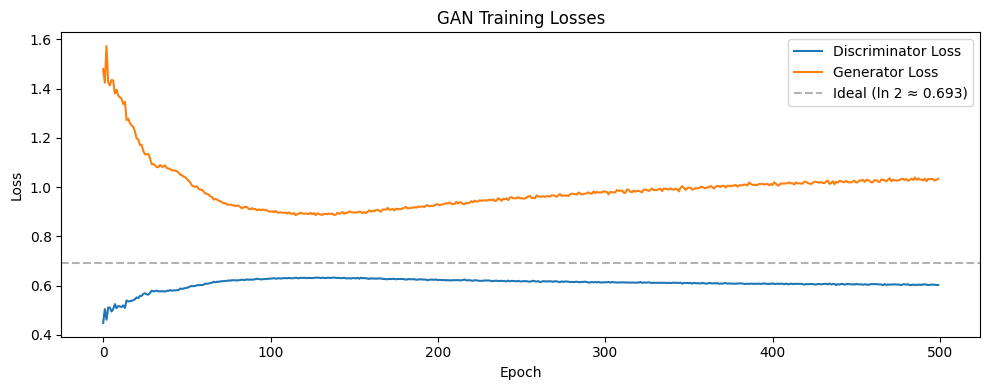

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.axhline(y=0.6931, color='gray', linestyle='--', alpha=0.6, label='Ideal (ln 2 ≈ 0.693)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.tight_layout()
plt.savefig('gan_loss_curve.png', dpi=150)
plt.show()

In [13]:
create_gif_from_images(image_save_base_dir, 'gan_training_progress.gif', fps=5)

GIF created at gan_training_progress.gif
